In [68]:
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm
import numpy as np

n, d = 2_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 1
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)
Sigma_W = np.eye(d_cov)

G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)

alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)

beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
sigma2_y = non_genetic_noise_y - h2_y_cov
gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)

s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)


z_s, b_s_raw = gwas_probit(G, s)[0:2] 
b_s_rescaled = b_s_raw * np.sqrt(1+snr_s) 
b_s = z_s / np.sqrt(len(s)) 
b_y = gwas_linear(G, y)[0] / np.sqrt(s.sum()) # we assume Var(y) = 1 

In [69]:
# Total variance of the latent selection: expected 1 + Var(W @ gamma_s)
print("Var(s*):", np.var(s_star))

# Conditional variance given W: expected 1
u_s = s_star - W @ gamma_s
print("Var(s* | W):", np.var(u_s))

# Variance explained by genetics: expected h2_s
print("Var(G @ alpha):", np.var(G @ alpha))

# Environmental noise: expected 1 - h2_s
eps_s_hat = u_s - G @ alpha
print("Var(eps_s):", np.var(eps_s_hat))

print("\nVar(y*):", np.var(y_star))
u_y = y_star - W @ gamma_y
print("Var(y* | W):", np.var(u_y))
print("Var(G @ beta):", np.var(G @ beta))
eps_y_hat = u_y - G @ beta
print("Var(eps_y):", np.var(eps_y_hat))

Var(s*): 1.2152077521088327
Var(s* | W): 0.9721250106097332
Var(G @ alpha): 0.4671779184733233
Var(eps_s): 0.5141139949199606

Var(y*): 1.0861464868957287
Var(y* | W): 0.812899305941118
Var(G @ beta): 0.5134659153842294
Var(eps_y): 0.31362472526311386


In [70]:
def resid(y, X):
    # Residuals from OLS of y on X
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

n = s_star.shape[0]
k_W = W.shape[1]
k_G = G.shape[1]

# Residuals after removing covariates only
r_W = resid(s_star, W)
# Residuals after removing covariates and genotypes
r_WG = resid(s_star, np.hstack([W, G]))

# Degrees-of-freedom corrected variances
var_cond_W = np.sum(r_W**2) / (n - k_W)            # Var(s* | W), expected 1
var_env = np.sum(r_WG**2) / (n - k_W - k_G)        # Var(eps_s), expected 1 - h2_s

# Variance explained by G given W, expected h2_s
print("Var(s* | W):", var_cond_W)
print("Var(eps_s):", var_env)
print("Var explained by G | W:", var_cond_W - var_env)

# Residuals after removing covariates only
r_W = resid(y_star, W)
# Residuals after removing covariates and genotypes
r_WG = resid(y_star, np.hstack([W, G]))

# Degrees-of-freedom corrected variances
var_cond_W = np.sum(r_W**2) / (n - k_W)            # Var(s* | W), expected 1
var_env = np.sum(r_WG**2) / (n - k_W - k_G)        # Var(eps_s), expected 1 - h2_s

# Variance explained by G given W, expected h2_s
print("\nVar(y* | W):", var_cond_W)
print("Var(eps_y):", var_env)
print("Var explained by G | W:", var_cond_W - var_env)

Var(s* | W): 0.9741739649153932
Var(eps_s): 0.5075200771516429
Var explained by G | W: 0.4666538877637503

Var(y* | W): 0.8140792388246885
Var(eps_y): 0.3105596969832495
Var explained by G | W: 0.503519541841439


# $h^2_s$ estimated using individual-level data

In [73]:
import gwas
reload(gwas)
from pcgc import pcgc_h2_s

# W must contain the intercept as the first column
h2_hat, se = pcgc_h2_s(s, G, W, n_jackknife=10)

In [74]:
h2_hat, h2_s_cond

(0.5500403440877477, 0.5)

In [96]:
h2_s_list = [i/20 for i in range(20)]

h2_estimates = {}   # h2 -> list of estimates
h2_ses = {}         # h2 -> list of jackknife SEs

rng = np.random.default_rng(42)

for h2_s in h2_s_list:
    h2_estimates[h2_s] = []
    h2_ses[h2_s] = []

    snr_s = h2_s / (1.0 - h2_s)
    print(h2_s)

    for i in range(100):
        G = sim.simulate_design_matrix(n, R, intercept=False, rng=rng)
        W = sim.simulate_design_matrix(n, Sigma_W, intercept=True, rng=rng)

        alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
        gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, intercept=True, rng=rng)

        beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
        sigma2_y = non_genetic_noise_y - h2_y_cov
        gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, intercept=True, rng=rng)

        s, y, s_star, y_star = sim.heckman_outcome(
            G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s, rng)

        # Jackknife is needed to get a per-simulation SE
        h2_hat, se = pcgc_h2_s(s, G, W, n_jackknife=10, rng=rng)

        h2_estimates[h2_s].append(h2_hat)
        h2_ses[h2_s].append(se)

0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95


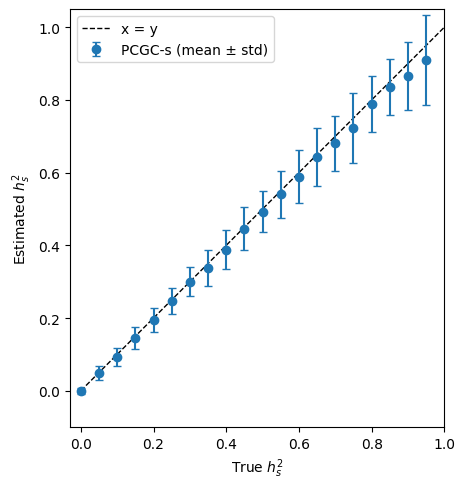

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Aggregate estimates across simulations
true_h2 = np.array(sorted(h2_estimates.keys()))
mean_h2 = np.array([np.mean(h2_estimates[h]) for h in true_h2])
std_h2 = np.array([np.std(h2_estimates[h], ddof=1) for h in true_h2])

fig, ax = plt.subplots(figsize=(5, 5))

# Identity line x = y
ax.plot([0, 1], [0, 1], "k--", lw=1, label="x = y")

# Mean estimate with +- 1 std across simulations
ax.errorbar(true_h2, mean_h2, yerr=std_h2, fmt="o", color="C0",
            capsize=3, label="PCGC-s (mean ± std)")

ax.set_xlabel("True $h^2_s$")
ax.set_ylabel("Estimated $h^2_s$")
ax.set_xlim(-0.03, 1.0)
ax.set_ylim(-0.1, 1.05)
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

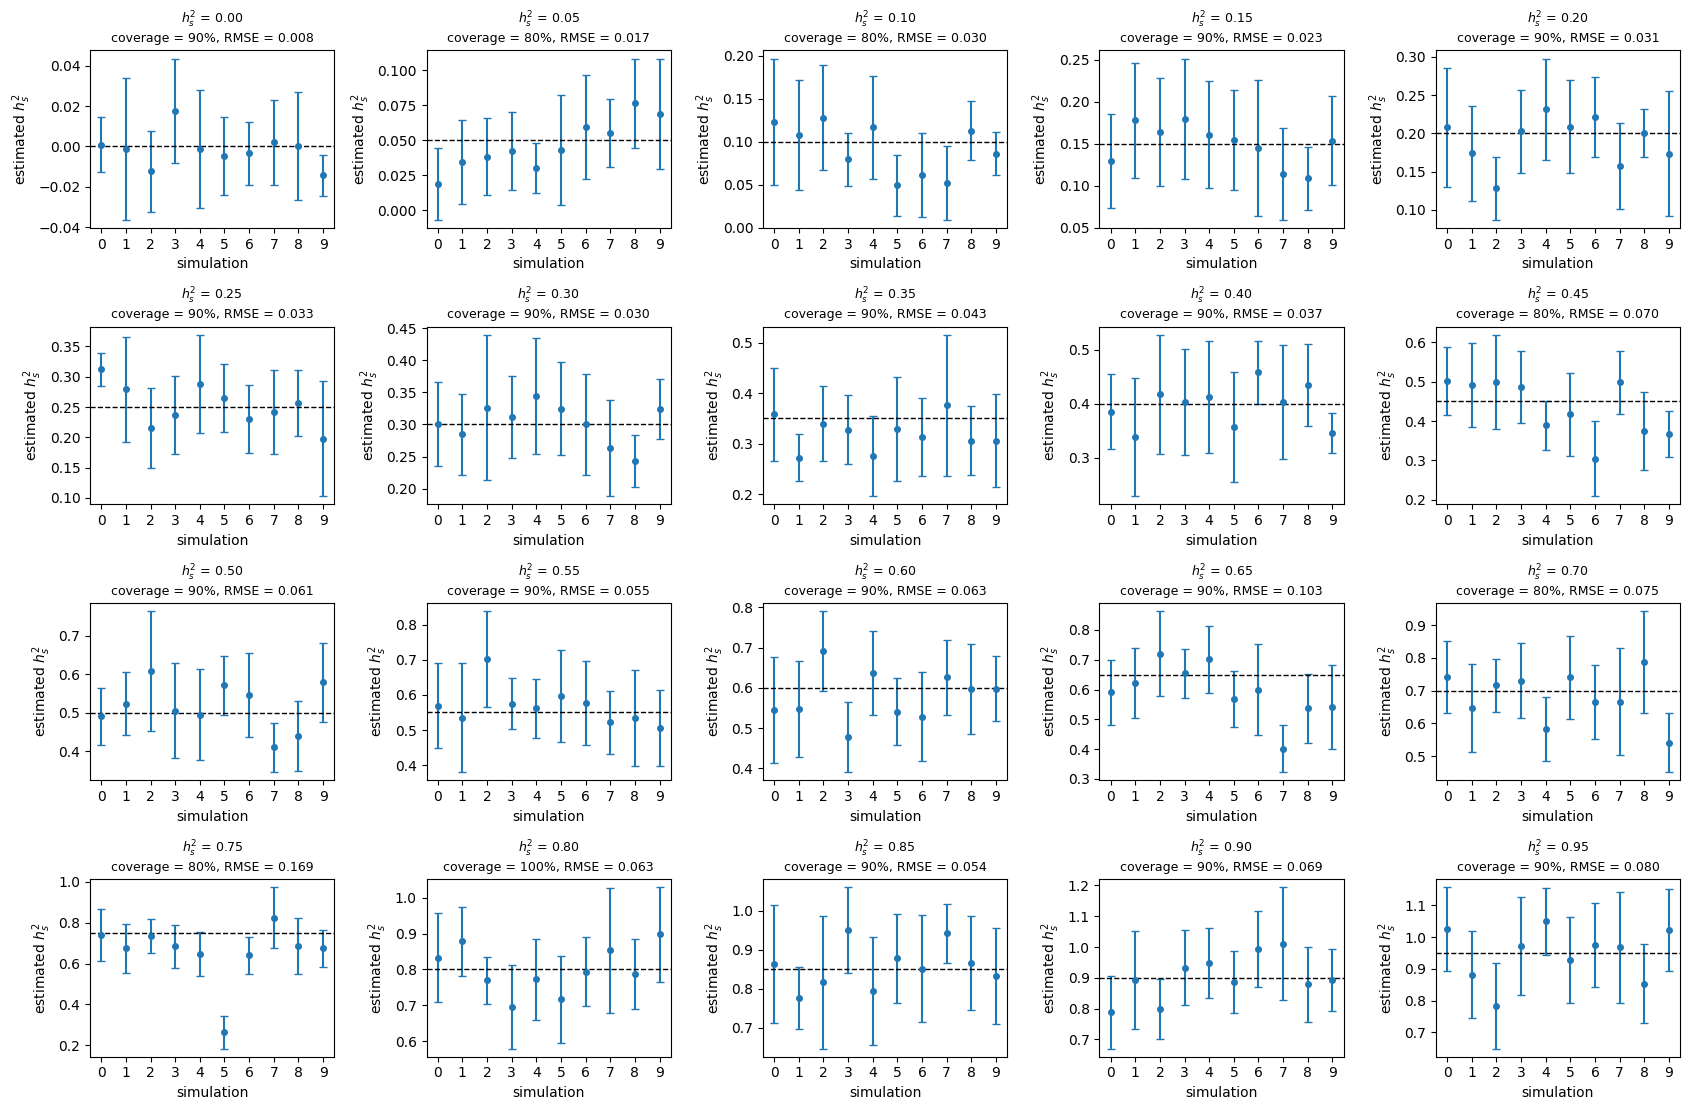

In [98]:
import numpy as np
import matplotlib.pyplot as plt

Z = 1.959964  # 97.5% quantile of the standard normal (95% CI)

h2_values = sorted(h2_estimates.keys())
n_cols = 5
n_rows = int(np.ceil(len(h2_values) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 2.8 * n_rows),
                         squeeze=False)
axes = axes.ravel()

for ax, h2 in zip(axes, h2_values):
    est = np.array(h2_estimates[h2][:10])
    se = np.array(h2_ses[h2][:10])
    seeds = np.arange(10)

    # 95% CI half-width
    half = Z * se
    lo, hi = est - half, est + half

    # Coverage: fraction of CIs containing the true h2; RMSE of the point estimates
    coverage = 100 * np.mean((lo <= h2) & (h2 <= hi))
    rmse = np.sqrt(np.mean((est - h2) ** 2))

    # Estimate per simulation with 95% CI whiskers on the y axis
    ax.errorbar(seeds, est, yerr=half, fmt="o", color="C0", capsize=3, ms=4)

    # True heritability as a horizontal line
    ax.axhline(h2, color="k", ls="--", lw=1)

    ax.set_title(f"$h^2_s$ = {h2:.2f}\ncoverage = {coverage:.0f}%, RMSE = {rmse:.3f}",
                 fontsize=9)
    ax.set_xlabel("simulation")
    ax.set_ylabel("estimated $h^2_s$")
    ax.set_xticks(seeds)

# Hide unused panels
for ax in axes[len(h2_values):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# $h^2_s$ estimated using summary stats data

In [99]:
import numpy as np
import pcgc
reload(pcgc)
from pcgc import pcgc_summary_stats, pcgc_s_h2

In [80]:
stats = pcgc_summary_stats(s, G, W)

h2, se = pcgc_s_h2(stats, n_jackknife=0)

In [81]:
h2, h2_s_cond

(0.7265712141757662, 0.5)

In [89]:
h2_s_list = [i/20 for i in range(20)]

h2_estimates_ss = {}   # h2 -> list of estimates
h2_ses_ss = {}         # h2 -> list of jackknife SEs

rng = np.random.default_rng(42)

for h2_s in h2_s_list:
    h2_estimates_ss[h2_s] = []
    h2_ses_ss[h2_s] = []

    snr_s = h2_s / (1.0 - h2_s)
    print(h2_s)

    for i in range(100):
        G = sim.simulate_design_matrix(n, R, intercept=False, rng=rng)
        W = sim.simulate_design_matrix(n, Sigma_W, intercept=True, rng=rng)

        alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
        gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, intercept=True, rng=rng)

        beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
        sigma2_y = non_genetic_noise_y - h2_y_cov
        gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, intercept=True, rng=rng)

        s, y, s_star, y_star = sim.heckman_outcome(
            G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s, rng)

        # Jackknife is needed to get a per-simulation SE
        stats = pcgc_summary_stats(s, G, W)
        h2_hat, se = pcgc_s_h2(stats, n_jackknife=10)

        h2_estimates_ss[h2_s].append(h2_hat)
        h2_ses_ss[h2_s].append(se)

0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9


/nfs/scistore17/robingrp/mpieczar/Jupyter/heckman_from_gwas/simulate_data.py:109: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.sqrt(h2/v) * beta_raw
/nfs/scistore17/robingrp/mpieczar/Jupyter/heckman_from_gwas/simulate_data.py:109: RuntimeWarning: invalid value encountered in multiply
  beta = np.sqrt(h2/v) * beta_raw


0.95


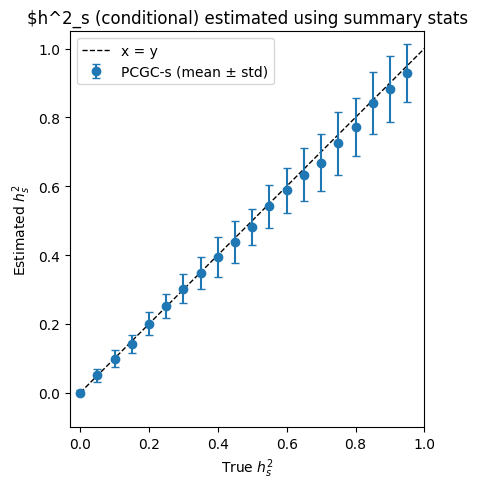

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Aggregate estimates across simulations
true_h2 = np.array(sorted(h2_estimates_ss.keys()))
mean_h2 = np.array([np.mean(h2_estimates_ss[h]) for h in true_h2])
std_h2 = np.array([np.std(h2_estimates_ss[h], ddof=1) for h in true_h2])

fig, ax = plt.subplots(figsize=(5, 5))

# Identity line x = y
ax.plot([0, 1], [0, 1], "k--", lw=1, label="x = y")

# Mean estimate with +- 1 std across simulations
ax.errorbar(true_h2, mean_h2, yerr=std_h2, fmt="o", color="C0",
            capsize=3, label="PCGC-s (mean ± std)")

ax.set_xlabel("True $h^2_s$")
ax.set_ylabel("Estimated $h^2_s$")
ax.set_xlim(-0.03, 1.0)
ax.set_ylim(-0.1, 1.05)
ax.set_aspect("equal")
ax.legend()
plt.title(r"$h^2_s (conditional) estimated using summary stats")
plt.tight_layout()
plt.show()

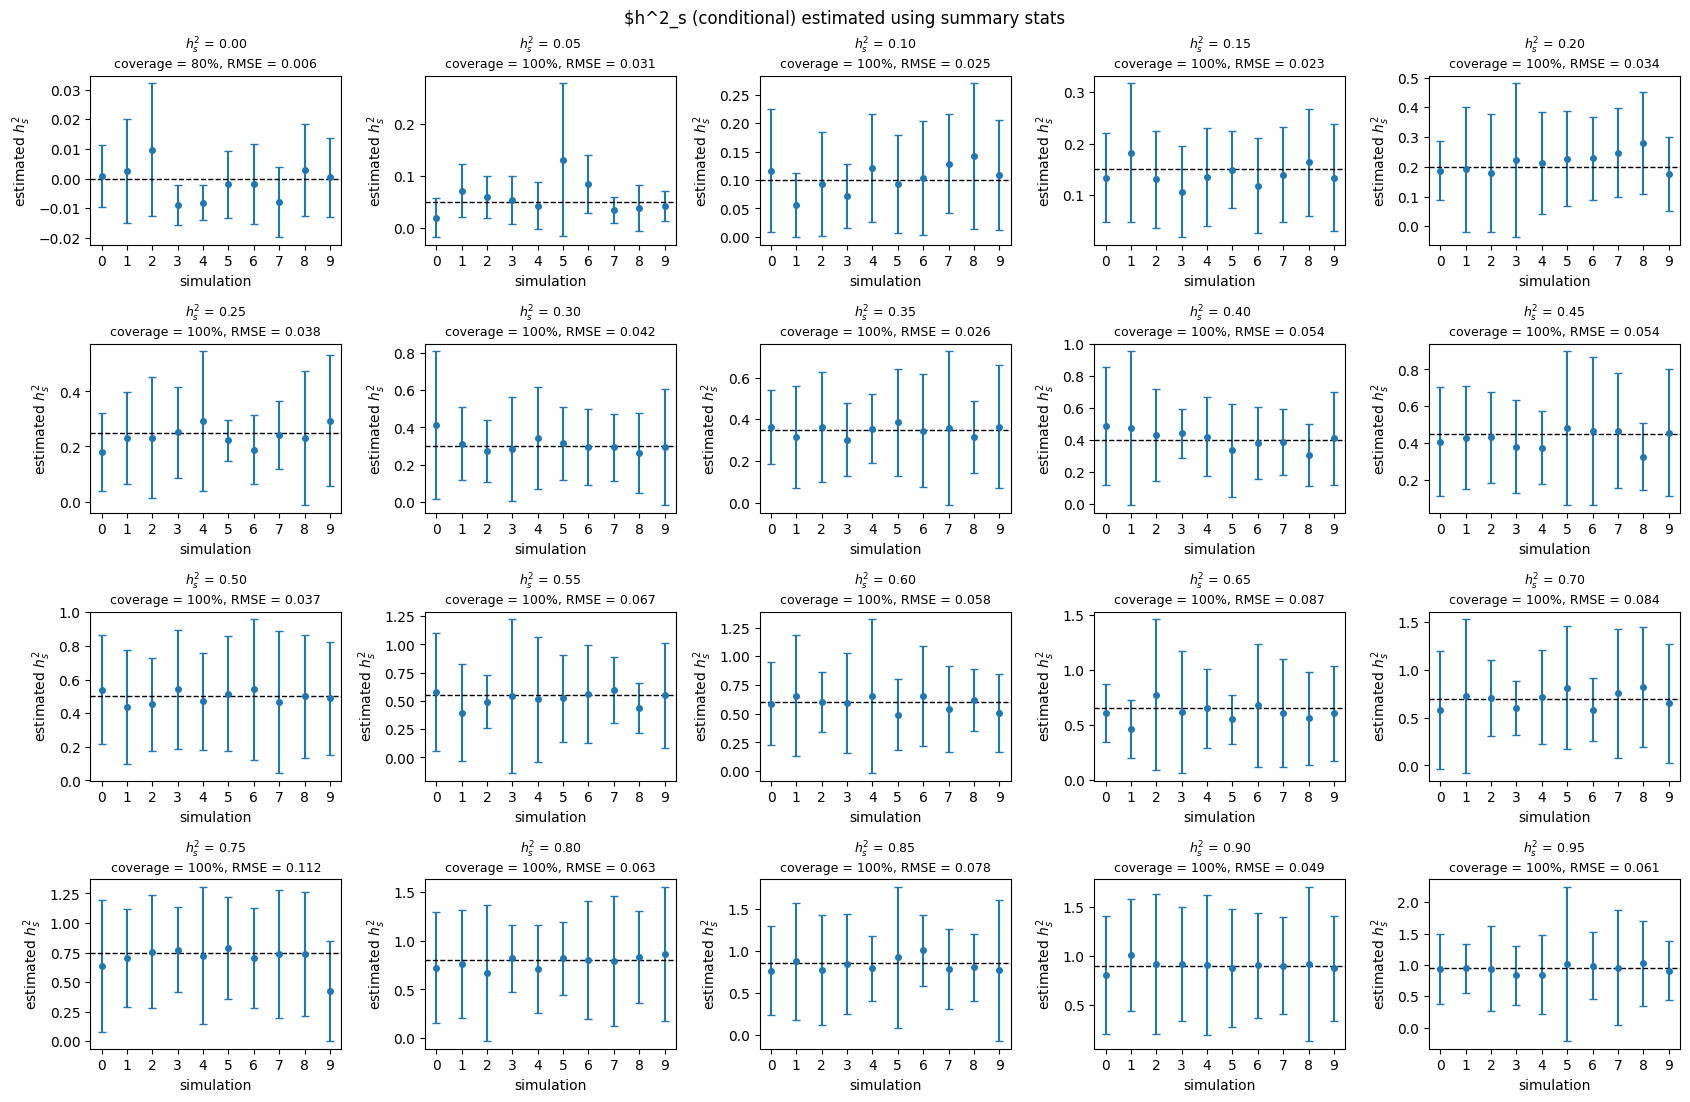

In [95]:
import numpy as np
import matplotlib.pyplot as plt

Z = 1.959964  # 97.5% quantile of the standard normal (95% CI)

h2_values = sorted(h2_estimates.keys())
n_cols = 5
n_rows = int(np.ceil(len(h2_values) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 2.8 * n_rows),
                         squeeze=False)
axes = axes.ravel()

for ax, h2 in zip(axes, h2_values):
    est = np.array(h2_estimates_ss[h2][:10])
    se = np.array(h2_ses_ss[h2][:10])
    seeds = np.arange(10)

    # 95% CI half-width
    half = Z * se
    lo, hi = est - half, est + half

    # Coverage: fraction of CIs containing the true h2; RMSE of the point estimates
    coverage = 100 * np.mean((lo <= h2) & (h2 <= hi))
    rmse = np.sqrt(np.mean((est - h2) ** 2))

    # Estimate per simulation with 95% CI whiskers on the y axis
    ax.errorbar(seeds, est, yerr=half, fmt="o", color="C0", capsize=3, ms=4)

    # True heritability as a horizontal line
    ax.axhline(h2, color="k", ls="--", lw=1)

    ax.set_title(f"$h^2_s$ = {h2:.2f}\ncoverage = {coverage:.0f}%, RMSE = {rmse:.3f}",
                 fontsize=9)
    ax.set_xlabel("simulation")
    ax.set_ylabel("estimated $h^2_s$")
    ax.set_xticks(seeds)

# Hide unused panels
for ax in axes[len(h2_values):]:
    ax.set_visible(False)

plt.suptitle(r"$h^2_s (conditional) estimated using summary stats")
plt.tight_layout()
plt.show()

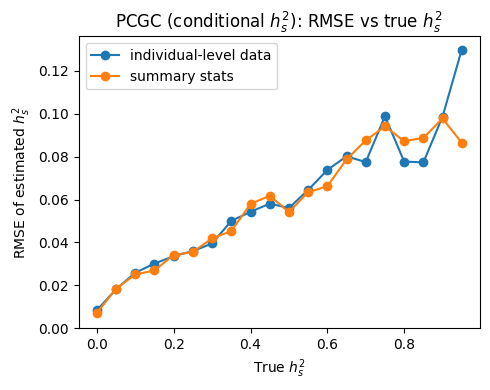

In [100]:
import numpy as np
import matplotlib.pyplot as plt

h2_values = np.array(sorted(h2_estimates.keys()))

# RMSE of the point estimates for each true h2
rmse_ind = np.array([
    np.sqrt(np.mean((np.array(h2_estimates[h]) - h) ** 2))
    for h in h2_values
])

rmse_ss = np.array([
    np.sqrt(np.mean((np.array(h2_estimates_ss[h]) - h) ** 2))
    for h in h2_values
])

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(h2_values, rmse_ind, "o-", label = "individual-level data")
ax.plot(h2_values, rmse_ss, "o-", label = "summary stats" )

ax.set_xlabel("True $h^2_s$")
ax.set_ylabel("RMSE of estimated $h^2_s$")
ax.set_title(r"PCGC (conditional $h^2_s$): RMSE vs true $h^2_s$")
ax.set_ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()